# SHAP-Guided Shooting Biomechanics — Capstone 2025-2026

End-to-end pipeline that turns marker-based biomechanics into per-shot coaching cues for a Unity 3D visualizer.

```
Biomechanics  ──Stage 1──►  Ball Flight Metrics  (diagnostic)
                  │
                  └──────►  Made / Miss Classifier  ──SHAP──►  Top hurting features per shot
                                                                       │
                                                               ──DiCE──►  Bounded counterfactual
                                                                       │
                                                                  Recommended pose (Unity CSV)
```

For each predicted-miss shot the system delivers:
- The player's **original pose** (`orig_*` joint angles, velocities, ROMs).
- A **recommended pose** (`rec_*`) produced by DiCE counterfactual search — only features that DiCE actually moved are surfaced as coaching cues.
- Per-shot SHAP attribution picks *which* features to vary; ANATOMICAL_BOUNDS + per-shot delta caps decide *how much* each one is allowed to move.

---

## What changed vs the original `phillip/shap_model` pipeline

**Recommendation engine (the big change)**
- **Replaced "median-of-makes + post-hoc ±12° cap" with DiCE Random counterfactual search over the Made classifier.** Bounds are now enforced upstream during sampling — no values are clipped after the fact, so DiCE naturally redistributes effort across joints when any single feature is tightly constrained ("power going to other variables").
- Per-feature search space is composed by `build_permitted_range`:
  `empirical 5–95 pctile  ∩  ANATOMICAL_BOUNDS  ∩  per-player feasibility  ∩  per-shot delta cap`.
- Coaching-scale delta caps applied *upstream*: ±15° for angles, ±20 % for velocities (min 0.5), ±20° for ROM.
- Derived/redundant features (`__zwithin`, `*DomDiff*`) are filtered out of `top_feats` so DiCE doesn't double-count.
- Output filters unchanged features: `Top_Feats` and skeleton `feat_<rank>` columns only list joints DiCE actually moved.

**Model wiring**
- Added an `LGBMClassifier` for `Made` (registered in `models`, `X_per_target`, `y_per_target`, `explainers_dict`). Previously absent; export functions had been silently falling back to `Max.Ball.Arc`, optimizing the wrong target.
- Made model always retrains on the current `X_full` schema to avoid stale-cache feature-count mismatches.

**Performance & cleanup**
- Cell 12 (Stage 1 ball-flight RFs) now uses `n_estimators=150, max_depth=12` and SHAP runs on a 1500-row subsample per group. Drops cell 16 runtime from ~12 min to ~30–90 s with negligible R² loss.
- Removed dead diagnostic cells: Stage-2 RF heatmap, Stage-3 BDFC sanity, free-throw parallel pipeline, summary-only markdown.
- Removed unused helpers from the bounds module (`COACHABILITY`, `coachability`, `make_plausibility_check`) and the diagnostic ball-flight DiCE loop.

**Methodology (kept from original)**
- `GroupKFold(groups=PlayerID)` for all CV scores.
- Sentinel cleanup (-1e9 markers → NaN).
- Circular std (`scipy.stats.circstd`) for alignment features.
- Per-player sample cap (500) so no single player dominates training.
- Strict context filter: `Shot.Distance / Type / Year / Days` allowed as model inputs (so the model accounts for shot difficulty) but excluded from the *recommendation* output — only biomechanical changes reach the coach.

---

## Running the notebook

The notebook runs top-to-bottom from a clean kernel. Single-player diagnostic mode targets `Player 163`. To process all players, set `RUN_ALL_PLAYERS = True` in Section 7 before running the batch runner in Section 9.

CSV outputs land in `unity_exports/` and `skeleton_exports/` and preserve the column schema of the original pipeline: `orig_<feat>` / `rec_<feat>` for every pose column plus per-shot metadata. Downstream Unity consumption is backward-compatible.

---

## Sections

1. **Setup** — imports, CSV load
2. **Preprocessing** — handedness normalization, sentinel cleanup, shot-type filter
3. **Feature engineering** — biomech selector, within-player z-scores, Dom/NonDom symmetry diffs, context features → `X_full`
4. **Stage 1** — biomechanics → ball-flight regressors (LightGBM, GroupKFold CV)
5. **Global SHAP** — diagnostic heatmap of ball-flight feature importances
6. **Made classifier** — drives all downstream per-shot recommendations
7. **Player analysis** — per-player scorecard, make/miss self-comparison, batch loop control
8. **Counterfactual search bounds** — ANATOMICAL_BOUNDS, delta caps, `build_permitted_range`
9. **Unity / skeleton export** — DiCE helpers, export functions, batch runner, Player 163 test
10. **Summary** — pipeline recap and CSV schema reference


## 1. Setup

Imports and CSV load. `capstone2026v2.csv` is searched in `./`, `../`, and the canonical capstone path. `numpy<2` is pinned because SHAP's TreeExplainer requires it.

In [61]:
%pip install -q "numpy<2" shap dice-ml lightgbm


Note: you may need to restart the kernel to use updated packages.


### Imports

In [62]:
import os, re, joblib, warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import shap
import dice_ml
from lightgbm import LGBMRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import cross_val_score, GroupKFold
from sklearn.neighbors import NearestNeighbors
from sklearn.preprocessing import RobustScaler
from scipy.stats import circstd, spearmanr

warnings.filterwarnings('ignore')
shap.initjs()
plt.rcParams['figure.dpi'] = 110
sns.set_style('whitegrid')


### Load `capstone2026v2.csv`

In [63]:
CSV_CANDIDATES = [
    'capstone2026v2.csv',
    '../capstone2026v2.csv',
    '/Users/shahil/Documents/UCSB/2025-2026/P3/capstone2026v2.csv',
]
DATA_PATH = next((p for p in CSV_CANDIDATES if os.path.exists(p)), None)
if DATA_PATH is None:
    raise FileNotFoundError('capstone2026v2.csv not found in any expected location.')

df_raw = pd.read_csv(DATA_PATH).rename(columns={'Name': 'PlayerID'})
print(f'Loaded {len(df_raw):,} shots × {df_raw.shape[1]} cols  |  '
      f'{df_raw.PlayerID.nunique()} players  |  '
      f'{df_raw.Date.min()} → {df_raw.Date.max()}')


Loaded 25,868 shots × 264 cols  |  165 players  |  1/18/2025 14:17 → 9/9/2024 9:18


## 2. Preprocessing

Standardizes handedness (mirrors left-handed shots into the dominant-hand frame, then renames `Right`/`Left` → `Dominant`/`NonDominant`), masks `|x| > 1e6` sentinel values to NaN, filters by `SHOT_GROUP`, and adds height-normalized release height + temporal features.

### Handedness mirroring

In [64]:
def _reflect_across_shot_axis(x, y):
    n = np.sqrt(x**2 + y**2)
    if n == 0:
        return x, y
    ux, uy = x / n, y / n
    px, py = (x*ux + y*uy) * ux, (x*ux + y*uy) * uy
    return x - 2*(x - px), y - 2*(y - py)


def standardize_handedness(df):
    df = df.copy()
    left = df['hand'] == 'Left'

    coords = df.loc[left, ['Shot.X.Pos', 'Shot.Y.Pos']].values
    if len(coords) > 0:
        ref = np.array([_reflect_across_shot_axis(x, y) for x, y in coords])
        df.loc[left, 'Shot.X.Pos'] = ref[:, 0]
        df.loc[left, 'Shot.Y.Pos'] = ref[:, 1]
    df.loc[left, 'Shot.X.Pos'] *= -1

    x_cols = [c for c in df.columns if re.search(r'(^|_)X($|[A-Z])', c)]
    y_cols = [c for c in df.columns if re.search(r'(^|_)Y($|[A-Z])', c)]
    for x_col, y_col in zip(x_cols, y_cols):
        coords = df.loc[left, [x_col, y_col]].values
        if len(coords) > 0:
            ref = np.array([_reflect_across_shot_axis(x, y) for x, y in coords])
            df.loc[left, x_col] = ref[:, 0]
            df.loc[left, y_col] = ref[:, 1]
        df.loc[left, x_col] *= -1

    for left_col in [c for c in df.columns if 'Left' in c]:
        right_col = left_col.replace('Left', 'Right')
        if right_col in df.columns:
            tmp = df.loc[left, left_col].copy()
            df.loc[left, left_col] = df.loc[left, right_col]
            df.loc[left, right_col] = tmp

    rename = {c: c.replace('Right', 'Dominant') for c in df.columns if 'Right' in c}
    rename.update({c: c.replace('Left', 'NonDominant') for c in df.columns if 'Left' in c})
    return df.rename(columns=rename)


### Apply preprocessing

In [65]:
SHOT_GROUP = 'JumpShots'   # 'JumpShots' | 'FreeThrow' | 'All'

df = standardize_handedness(df_raw)

# Sentinel cleanup -- 8 alignment cols had -1e9 markers (10 rows total).
num_cols = df.select_dtypes('number').columns
n_sentinels = int((df[num_cols].abs() > 1e6).sum().sum())
df[num_cols] = df[num_cols].mask(df[num_cols].abs() > 1e6)
print(f'Cleaned {n_sentinels} sentinel cells (|x| > 1e6 → NaN)')

# Free throws are mechanically distinct -- model them separately.
if SHOT_GROUP == 'JumpShots':
    df = df[df['Shot.Location'] != 'Free Throw'].copy()
elif SHOT_GROUP == 'FreeThrow':
    df = df[df['Shot.Location'] == 'Free Throw'].copy()

# Height-normalized release: drops the "tall players release high" trivial signal
if {'Release.Height', 'ht'}.issubset(df.columns):
    df['Release.Height.Norm'] = df['Release.Height'] / df['ht']

# Temporal features
df['Date'] = pd.to_datetime(df['Date'], errors='coerce')
df['Year'] = df['Date'].dt.year
df['DaysSinceFirstShot'] = (df['Date'] - df.groupby('PlayerID')['Date'].transform('min')).dt.days

print(f'{SHOT_GROUP}: {len(df):,} shots × {df.PlayerID.nunique()} players')


Cleaned 10 sentinel cells (|x| > 1e6 → NaN)
JumpShots: 21,901 shots × 165 players


## 3. Feature engineering

Token-matched biomech feature selector (`select_biomech`), within-player z-scores (linear for bounded features, circular for alignment columns), and Dom/NonDom symmetry diffs. The final `X_full` matrix (~546 columns) combines raw biomech + zwithin + symmetry + context features.

### Feature utilities

Token-matched biomech selector, circular angle helpers, within-player z-score, and Dom/NonDom symmetry diff.

In [66]:
BIO_KEYWORDS = ['ankle','knee','hip','shoulder','elbow','torso','wrist',
                'flexion','extension','alignment','rom','velocity','velo',
                'dorsiflexion','plantarflexion','stance','gap']
EXCLUDE_KEYWORDS = ['time','made','shot.location','shot.type','shot.x','shot.y',
                    'pos.x','pos.y','pos.z','distance.from','date','name','playerid','hand']
KNOWN_TARGETS = {
    'Ball_to_Rim_Angle','Ball_Velocity','Release.Height','Release.Height.Norm',
    'Initial.Ball.Angle','Initial.Ball.Velocity','Max.Ball.Arc',
    'Made','Ball.Distance.from.Center','Shot.X.Pos','Shot.Y.Pos',
}


# ── Circular-angle utilities ────────────────────────────────────────────────
# Only Hip/Shoulder/Feet alignment columns are truly circular (range [-180, 180]
# with wrap). Flexion / ROM / velocity are bounded linear -- no wrap.
def is_circular(name):
    return 'alignment' in name.lower()


def circular_diff(a, b, period=360, half=180):
    """Shortest-arc a - b, returned in [-half, half]. Vectorized."""
    return ((np.asarray(a) - np.asarray(b) + half) % period) - half


def circular_mean(values, period=360, half=180):
    """Mean angle in [-half, half]. Returns NaN if empty."""
    arr = np.asarray(pd.Series(values).dropna(), dtype=float)
    if len(arr) == 0:
        return float('nan')
    rad = np.deg2rad(arr)
    return float(np.rad2deg(np.arctan2(np.sin(rad).mean(), np.cos(rad).mean())))


def select_biomech(df):
    """Pick biomechanical feature columns by token match (so 'x' won't match 'flexion')."""
    out = []
    for c in df.columns:
        if c in KNOWN_TARGETS:
            continue
        cl = c.lower()
        tokens = set(re.split(r'[._\- ]+', cl))
        if tokens & set(EXCLUDE_KEYWORDS):
            continue
        if any(k in cl for k in BIO_KEYWORDS):
            out.append(c)
    return out


def add_within_player(df, cols, group='PlayerID'):
    """Adds <col>__zwithin = z-score within each player.

    Linear (mean, std) for bounded features. For circular alignment columns:
    centers via circular_mean and scales by circstd, with circular subtraction
    so a shot at +175 vs player-mean -175 gets z ≈ 0 (10° arc), not z = huge.
    """
    out = df.copy()
    for c in cols:
        if c not in df.columns:
            continue
        if is_circular(c):
            cm = df.groupby(group)[c].transform(
                lambda g: circular_mean(g) if g.notna().any() else np.nan
            )
            cs = df.groupby(group)[c].transform(
                lambda g: float(circstd(g.dropna().values, high=180, low=-180))
                          if g.notna().sum() > 1 else np.nan
            ).replace(0, np.nan)
            d = circular_diff(df[c].values, cm.values)
            out[f'{c}__zwithin'] = pd.Series(d, index=df.index).div(cs).fillna(0)
        else:
            m = df.groupby(group)[c].transform('mean')
            s = df.groupby(group)[c].transform('std').replace(0, np.nan)
            out[f'{c}__zwithin'] = ((df[c] - m) / s).fillna(0)
    return out


def add_symmetry(df):
    """Dom - NonDom diff for each paired column. (Ratios were tested and add no held-out signal.)"""
    out = df.copy()
    new = []
    for c in df.columns:
        if 'NonDominant' in c or 'Dominant' not in c:
            continue
        partner = c.replace('Dominant', 'NonDominant')
        if partner in df.columns:
            diff = c.replace('Dominant', 'DomDiff')
            # Alignment columns aren't paired Dom/NonDom (they're whole-segment),
            # so circular handling isn't needed here in practice.
            out[diff] = df[c] - df[partner]
            new.append(diff)
    return out, new


### Assemble `X_full`

Combines `BIOMECH_FEATURES` + `ZWITHIN_FEATURES` + `SYMMETRY_FEATURES` + context columns. The full feature matrix is what every downstream model trains on.

In [67]:
BIOMECH_FEATURES = list(df[select_biomech(df)].select_dtypes('number').columns)

df = add_within_player(df, BIOMECH_FEATURES)
ZWITHIN_FEATURES = [f'{c}__zwithin' for c in BIOMECH_FEATURES if f'{c}__zwithin' in df.columns]

df, SYMMETRY_FEATURES = add_symmetry(df)

ctx_pieces, ctx_names = [], []
if 'Shot.Distance' in df.columns:
    ctx_pieces.append(df[['Shot.Distance']]); ctx_names.append('Shot.Distance')
if 'Shot.Type' in df.columns:
    st = pd.get_dummies(df['Shot.Type'], prefix='ShotType', dtype=int)
    ctx_pieces.append(st); ctx_names += st.columns.tolist()
if 'Year' in df.columns:
    ctx_pieces.append(df[['Year', 'DaysSinceFirstShot']])
    ctx_names += ['Year', 'DaysSinceFirstShot']
CONTEXT_FEATURES = ctx_names

X_full = pd.concat([df[BIOMECH_FEATURES], df[ZWITHIN_FEATURES],
                    df[SYMMETRY_FEATURES] if SYMMETRY_FEATURES else None,
                    *ctx_pieces], axis=1)
X_full = X_full.loc[:, ~X_full.columns.duplicated()]

print(f'X_full = {X_full.shape[1]} cols  '
      f'(biomech {len(BIOMECH_FEATURES)} + zwithin {len(ZWITHIN_FEATURES)} + '
      f'symmetry {len(SYMMETRY_FEATURES)} + context {len(CONTEXT_FEATURES)})')

counts = df.PlayerID.value_counts()
print(f'Shots/player: median {counts.median():.0f}  max {counts.max()}  '
      f'(top: {counts.index[0]}, {counts.iloc[0]/len(df):.1%} of dataset)')


X_full = 546 cols  (biomech 206 + zwithin 206 + symmetry 130 + context 5)
Shots/player: median 76  max 2873  (top: Player 163, 13.1% of dataset)


## 4. Stage 1 — Biomechanics → Ball Flight

LightGBM regressors for four ball-flight targets (`Release.Height.Norm`, `Initial.Ball.Angle`, `Initial.Ball.Velocity`, `Max.Ball.Arc`). Per-player sample cap (500) prevents any single player from dominating training. CV uses `GroupKFold(groups=PlayerID)` so no player straddles train/test.

### Train Stage-1 ball-flight regressors

In [68]:
BDFC = 'Ball.Distance.from.Center'

BALL_FLIGHT_TARGETS = [
    'Release.Height.Norm', 'Initial.Ball.Angle',
    'Initial.Ball.Velocity', 'Max.Ball.Arc',
]
R2_MIN_FOR_DICE = 0.20
PER_PLAYER_CAP = 500
MODEL_DIR = 'saved_models'
os.makedirs(MODEL_DIR, exist_ok=True)


def cap_per_player(X, y, groups, cap=PER_PLAYER_CAP, seed=42):
    if cap is None:
        return X, y, groups
    rng = np.random.default_rng(seed)
    g = pd.Series(groups, index=X.index)
    keep = pd.Series(True, index=X.index)
    for player, n in g.value_counts().items():
        if n > cap:
            idx = X.index[g == player]
            drop = rng.choice(idx.values, size=n - cap, replace=False)
            keep.loc[drop] = False
    return X[keep], y[keep], np.asarray(groups)[keep.values]


models, metrics, X_per_target, y_per_target = {}, {}, {}, {}

for target in BALL_FLIGHT_TARGETS:
    if target not in df.columns:
        continue
    cache = os.path.join(MODEL_DIR, f'lgbm_{SHOT_GROUP}_{target.replace(".","_")}.pkl')

    data = pd.concat([X_full, df[target]], axis=1).dropna()
    X_clean, y_clean = data[X_full.columns], data[target]
    g_clean = df.loc[X_clean.index, 'PlayerID'].values

    X_fit, y_fit, g_fit = cap_per_player(X_clean, y_clean, g_clean)

    # Always retrain to ensure feature compatibility with current X_full
    model = LGBMRegressor(n_estimators=500, learning_rate=0.05, random_state=42, verbose=-1)
    model.fit(X_fit, y_fit)
    joblib.dump(model, cache)
    src = 'trained'

    preds = model.predict(X_clean)
    r2_train = r2_score(y_clean, preds)
    mae = mean_absolute_error(y_clean, preds)
    rmse = np.sqrt(mean_squared_error(y_clean, preds))

    cv_est = LGBMRegressor(n_estimators=500, learning_rate=0.05, random_state=42, verbose=-1)
    r2_cv = float(np.mean(cross_val_score(
        cv_est, X_fit, y_fit,
        cv=GroupKFold(5).split(X_fit, y_fit, groups=g_fit),
        scoring='r2', n_jobs=-1
    )))

    models[target] = model
    metrics[target] = {'R2': r2_cv, 'R2_train': r2_train, 'MAE': mae, 'RMSE': rmse}
    X_per_target[target] = X_clean
    y_per_target[target] = y_clean

    flag = '' if r2_cv >= R2_MIN_FOR_DICE else f'  (below R²_MIN, DiCE will skip)'
    print(f'[{src}] {target:24s}  R²_cv={r2_cv:.3f}  R²_train={r2_train:.3f}  '
          f'MAE={mae:.4f}  RMSE={rmse:.4f}{flag}')

pd.DataFrame(metrics).T.round(4).style.background_gradient(subset=['R2'], cmap='RdYlGn')


[trained] Release.Height.Norm       R²_cv=0.676  R²_train=0.975  MAE=0.0003  RMSE=0.0004
[trained] Initial.Ball.Angle        R²_cv=0.533  R²_train=0.887  MAE=0.8024  RMSE=1.4228
[trained] Initial.Ball.Velocity     R²_cv=0.877  R²_train=0.976  MAE=0.0710  RMSE=0.1350
[trained] Max.Ball.Arc              R²_cv=0.569  R²_train=0.956  MAE=0.0513  RMSE=0.0742


,R2,R2_train,MAE,RMSE
Release.Height.Norm,0.675800,0.974800,0.000300,0.000400
Initial.Ball.Angle,0.532500,0.886700,0.802400,1.422800
Initial.Ball.Velocity,0.876700,0.975800,0.071000,0.135000
Max.Ball.Arc,0.568600,0.955900,0.051300,0.074200


## 5. Global SHAP — biomech features driving ball flight

**Diagnostic only** — does not feed the recommendation pipeline. Computes per-target SHAP on a 5k random sample and produces a cross-target ranking heatmap to confirm which biomech features matter most across ball-flight outcomes.

### Global SHAP (diagnostic heatmap)

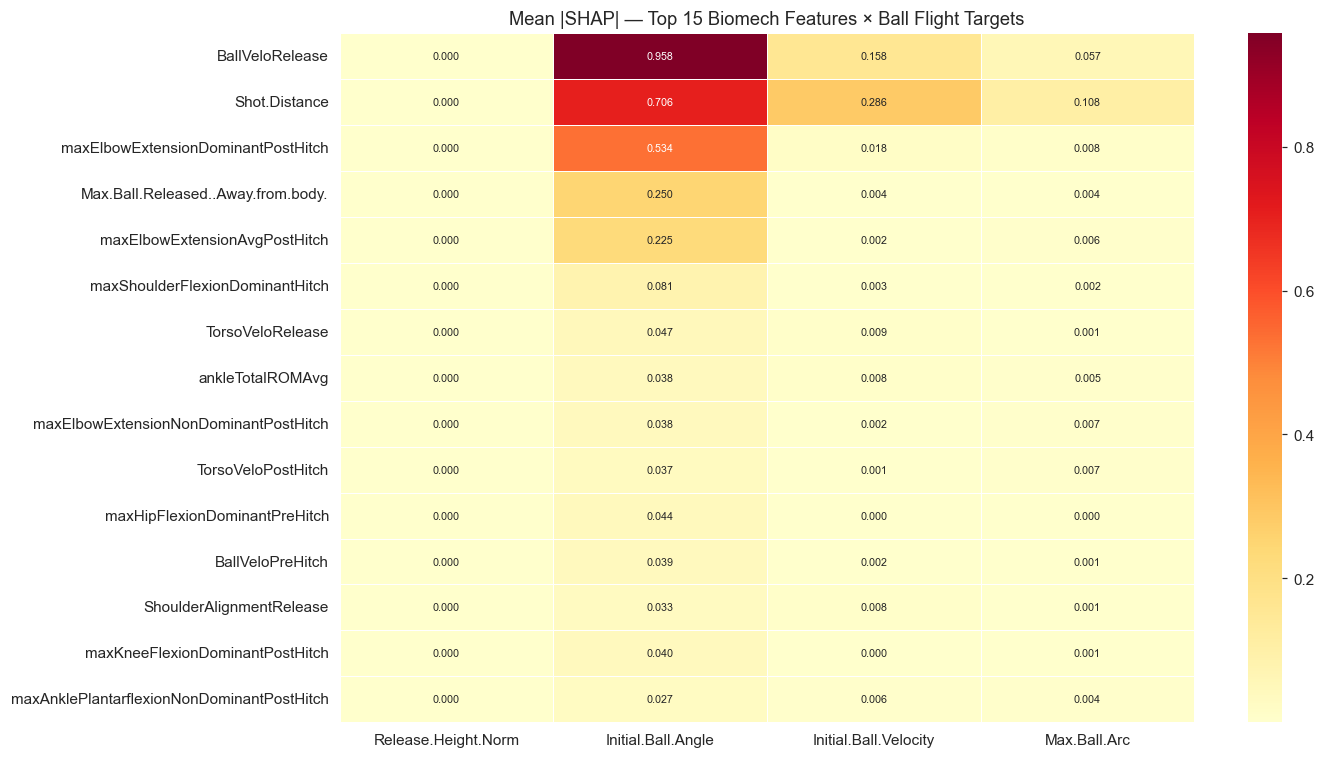

In [69]:
SHAP_SAMPLE = 5000
shap_values_dict, explainers_dict, shap_samples_dict = {}, {}, {}

for target in BALL_FLIGHT_TARGETS:
    X = X_per_target[target]
    samp = X.sample(min(SHAP_SAMPLE, len(X)), random_state=42)
    expl = shap.TreeExplainer(models[target])
    sv = expl.shap_values(samp)
    shap_values_dict[target] = sv
    explainers_dict[target] = expl
    shap_samples_dict[target] = samp

# Cross-target ranking
ranks = []
for t in BALL_FLIGHT_TARGETS:
    s = pd.Series(np.abs(shap_values_dict[t]).mean(axis=0),
                  index=shap_samples_dict[t].columns, name=t)
    ranks.append(s)
cross_df = pd.concat(ranks, axis=1)
cross_df['mean_rank'] = cross_df.mean(axis=1)
cross_df = cross_df.sort_values('mean_rank', ascending=False)

biomech_cross = cross_df[cross_df.index.isin(BIOMECH_FEATURES)]

fig, ax = plt.subplots(figsize=(13, 7))
sns.heatmap(biomech_cross.head(15)[BALL_FLIGHT_TARGETS],
            cmap='YlOrRd', ax=ax, linewidths=0.4, annot=True, fmt='.3f',
            annot_kws={'size': 7})
ax.set_title('Mean |SHAP| — Top 15 Biomech Features × Ball Flight Targets', fontsize=12)
plt.tight_layout()
plt.show()


## 6. Made classifier (drives per-shot recommendations)

Trains an `LGBMClassifier` on the `Made` label and registers it in `models['Made']`, `X_per_target['Made']`, `y_per_target['Made']`, `explainers_dict['Made']`. **This is the model SHAP and DiCE operate on downstream.** Always retrains (no cache load) so the feature count stays in sync with the current `X_full`.

### Train + register the Made classifier

In [70]:
from lightgbm import LGBMClassifier

made_data = pd.concat([X_full, df['Made']], axis=1).dropna()
X_m, y_m = made_data[X_full.columns], made_data['Made'].astype(int)
g_m = df.loc[X_m.index, 'PlayerID'].values
X_fit_m, y_fit_m, g_fit_m = cap_per_player(X_m, y_m, g_m)

# Always retrain to stay in sync with current X_full schema
made_cache = os.path.join(MODEL_DIR, f'lgbm_{SHOT_GROUP}_Made.pkl')
made_model = LGBMClassifier(n_estimators=500, learning_rate=0.05,
                            random_state=42, verbose=-1)
made_model.fit(X_fit_m, y_fit_m)
joblib.dump(made_model, made_cache)

models['Made']          = made_model
X_per_target['Made']    = X_m
y_per_target['Made']    = y_m
explainers_dict['Made'] = shap.TreeExplainer(made_model)

acc = float((made_model.predict(X_m) == y_m).mean())
auc_cv = float(np.mean(cross_val_score(
    LGBMClassifier(n_estimators=500, learning_rate=0.05, random_state=42, verbose=-1),
    X_fit_m, y_fit_m,
    cv=GroupKFold(5).split(X_fit_m, y_fit_m, groups=g_fit_m),
    scoring='roc_auc', n_jobs=-1
)))
print(f'Made classifier registered: n={len(X_m):,}  '
      f'train acc={acc:.3f}  AUC_cv={auc_cv:.3f}')


Made classifier registered: n=21,899  train acc=0.882  AUC_cv=0.571


## 7. Player analysis — Player 163

Three cells: single-player make/miss self-comparison and consistency-vs-peers diagnostics; ball-flight scorecard (where does the player sit relative to the made-shot optimal band per target); batch-loop control (`RUN_ALL_PLAYERS`, `PLAYER_IDS_TO_PROCESS`).

### Single-player self-compare

For the test player: make/miss median deltas with effect size (Δ / shot-to-shot std, using circular std for alignment columns), plus consistency rank vs height-matched peers.

In [71]:
PLAYER_ID = 'Player 163'
MIN_SHOTS = 20

p_mask = df.PlayerID == PLAYER_ID
p_shots = df[p_mask]
n_p = len(p_shots)
form_score = p_shots.Made.mean()
avg_miss = p_shots[BDFC].mean()

# Role-matched peers (height ± 3 in)
peers = df.copy()
if 'ht' in df.columns and p_shots.ht.notna().any():
    p_ht = float(p_shots.ht.median())
    peers = df[(df.ht.between(p_ht - 3, p_ht + 3)) & (df.PlayerID != PLAYER_ID)]
    peer_label = f'height {p_ht-3:.0f}–{p_ht+3:.0f} in'
else:
    peer_label = 'all players'

print(f'{PLAYER_ID} — {n_p:,} shots')
print(f'  Form score (test-shot make rate) : {form_score:.1%}  '
      f'(pool {df.Made.mean():.1%}, peers {peers.Made.mean():.1%})')
print(f'  Avg miss distance               : {avg_miss:.2f} cm  '
      f'(pool {df[BDFC].mean():.2f}, peers {peers[BDFC].mean():.2f})')
print(f'  Peer cohort                     : {peers.PlayerID.nunique()} players ({peer_label})')


def smart_std(s, name):
    s = pd.Series(s).dropna()
    if len(s) < 2:
        return float('nan')
    if 'alignment' in name.lower():
        return float(circstd(s.values, high=180, low=-180))
    return float(s.std())


# Make / miss self-comparison
# For circular alignment columns: summary uses circular_mean and delta uses
# shortest-arc circular_diff. Without this, a player whose makes cluster at
# +175 and misses at -175 would get a phantom +350 delta when the true arc
# distance is just 10 deg.
def _summary(values, name):
    """Robust summary: median for linear, circular mean for circular angles."""
    s = pd.Series(values).dropna()
    if len(s) == 0:
        return float('nan')
    return circular_mean(s.values) if is_circular(name) else float(s.median())

makes = p_shots[p_shots.Made == 1]
misses = p_shots[p_shots.Made == 0]
self_compare_rows = []
if len(makes) >= 5 and len(misses) >= 5:
    biomech_cols = [c for c in BIOMECH_FEATURES if c in p_shots.columns]
    for c in biomech_cols:
        make_s = _summary(makes[c], c)
        miss_s = _summary(misses[c], c)
        if pd.isna(make_s) or pd.isna(miss_s):
            continue
        if is_circular(c):
            delta = float(circular_diff(miss_s, make_s))
        else:
            delta = miss_s - make_s
        std = smart_std(p_shots[c], c)
        if pd.isna(std) or std == 0:
            continue
        eff = abs(delta) / std
        self_compare_rows.append({'feature': c,
                                  'make_median': float(make_s),
                                  'miss_median': float(miss_s),
                                  'delta': float(delta),
                                  'effect': float(eff)})
self_compare = pd.DataFrame(self_compare_rows).sort_values('effect', ascending=False)

print(f'\nMake/miss self-comparison: {len(makes)} makes vs {len(misses)} misses')
print(f'(Effect = |miss - make| / shot-to-shot std; circ-std for alignments)\n')
for _, r in self_compare.head(8).iterrows():
    flag = '  *' if r.effect >= 0.5 else ''
    print(f"  {r.feature:48s}  Δ={r.delta:+8.3f}  effect={r.effect:.2f}{flag}")

self_compare_priority = self_compare[self_compare.effect >= 0.5].to_dict('records')


# Consistency vs role-matched peers
biomech_cols = [c for c in BIOMECH_FEATURES if c in df.columns]
peer_qual = peers.PlayerID.value_counts()
peer_qual = peer_qual[peer_qual >= MIN_SHOTS].index.tolist()
cohort_ids = peer_qual + [PLAYER_ID]

cohort_stds = pd.DataFrame({
    pid: {c: smart_std(df[df.PlayerID == pid][c], c) for c in biomech_cols}
    for pid in cohort_ids
}).T

consistency_flags = []
if PLAYER_ID in cohort_stds.index and len(cohort_stds) >= 4:
    pctile = cohort_stds.rank(pct=True).loc[PLAYER_ID] * 100
    high = pctile[pctile >= 75].sort_values(ascending=False).head(8)
    if len(high) > 0:
        print(f'\nConsistency: top 25% of variance vs {len(peer_qual)} peers')
        for feat, p in high.items():
            std = float(cohort_stds.loc[PLAYER_ID, feat])
            if pd.isna(std):
                continue
            print(f"  {feat:48s}  std={std:7.3f}  ({p:.0f}th pctile)")
            consistency_flags.append({'feature': feat, 'player_std': std, 'pctile': float(p)})


Player 163 — 2,873 shots
  Form score (test-shot make rate) : 64.1%  (pool 62.3%, peers 59.3%)
  Avg miss distance               : 5.44 cm  (pool 5.36, peers 5.57)
  Peer cohort                     : 82 players (height 79–85 in)

Make/miss self-comparison: 1842 makes vs 1031 misses
(Effect = |miss - make| / shot-to-shot std; circ-std for alignments)

  maxTorsoFlexionHitch                              Δ=  -0.797  effect=0.27
  maxAnkleDorsiflexionDominantPreHitch              Δ=  -1.927  effect=0.27
  TorsoVeloPostHitch                                Δ=  +0.129  effect=0.26
  maxTorsoExtensionPreHitch                         Δ=  -0.785  effect=0.26
  MaxStanceGapRelease                               Δ=  -0.016  effect=0.25
  BallVeloPreHitch                                  Δ=  +0.229  effect=0.25
  maxAnkleDorsiflexionAvgPreHitch                   Δ=  -1.146  effect=0.23
  maxAnklePlantarflexionDominantPreHitch            Δ=  -1.772  effect=0.22

Consistency: top 25% of variance vs 69

### Ball-flight scorecard

Compares the player's actual median ball-flight metrics against the 40–60th percentile of made shots. A target is flagged as a *priority* when the gap exceeds both `2·SE_player` and the model's RMSE, and the CV R² is high enough to trust the model (`R2_MIN_FOR_DICE = 0.20`). Diagnostic only — does not feed the export.

In [72]:
# Ball-flight scorecard: actual-vs-actual, made-shot reference, optimal band
# A target qualifies as a priority only if:
#   1. player's actual median falls outside the 40-60 pctile of MADE shots
#   2. gap > max(2*SE_player, model RMSE)  -- statistically distinguishable
#   3. CV R² >= R2_MIN_FOR_DICE             -- model is good enough for a CF

weak_targets, scorecard = [], []

for target in BALL_FLIGHT_TARGETS:
    if target not in y_per_target:
        continue
    if is_circular(target):
        # Linear pctile is wrong for circular variables. None of the current
        # targets are circular; this guard is here so the scorecard fails loudly
        # if a circular target is added later.
        print(f'[skip] {target} is circular -- linear quantile band not implemented')
        continue
    X_t = X_per_target[target]
    pid_idx = df.loc[X_t.index, 'PlayerID'] == PLAYER_ID
    p_actual = df.loc[X_t.index, target][pid_idx].dropna()
    if len(p_actual) < MIN_SHOTS:
        continue

    actual_med = float(p_actual.median())
    se = (p_actual.std() / np.sqrt(len(p_actual))) if len(p_actual) > 1 else 0.0
    y_made = y_per_target[target][df.loc[X_t.index, 'Made'] == 1]
    lo, hi = float(y_made.quantile(0.40)), float(y_made.quantile(0.60))

    if actual_med < lo:
        gap, direction = lo - actual_med, 'increase'
    elif actual_med > hi:
        gap, direction = actual_med - hi, 'decrease'
    else:
        gap, direction = 0.0, 'in band'

    rmse = metrics[target]['RMSE']
    r2 = metrics[target]['R2']
    is_priority = gap > max(2*se, rmse) and r2 >= R2_MIN_FOR_DICE

    scorecard.append({
        'Metric': target, 'Player': round(actual_med, 3),
        'Optimal Lo': round(lo, 3), 'Optimal Hi': round(hi, 3),
        'Gap': round(gap, 3) if gap > 0 else '—',
        'CV R²': round(r2, 3),
        'Status': direction.upper() + (' *PRIORITY*' if is_priority else ''),
    })
    if is_priority:
        weak_targets.append(dict(target=target, actual_med=actual_med,
                                 target_lo=lo, target_hi=hi, gap=gap,
                                 rmse=rmse, r2=r2,
                                 direction=direction,
                                 X_player=X_t[pid_idx]))

display(pd.DataFrame(scorecard).style.hide(axis='index'))

# Headline drill targets — combines both gates
print(f"\n{'─'*70}\nHEADLINE DRILL TARGETS for {PLAYER_ID}\n{'─'*70}")
if not weak_targets and not self_compare_priority:
    print('No priority drills triggered — mechanics look sound on every gate.')
for i, wt in enumerate(weak_targets, 1):
    print(f"  P{i} (ball-flight): {wt['target']}, {wt['direction']} from "
          f"{wt['actual_med']:.3f} toward [{wt['target_lo']:.3f}, {wt['target_hi']:.3f}]")
for i, sp in enumerate(self_compare_priority, 1):
    print(f"  S{i} (self-compare): {sp['feature']}, "
          f"miss-make Δ={sp['delta']:+.2f}, effect={sp['effect']:.2f}")


Metric,Player,Optimal Lo,Optimal Hi,Gap,CV R²,Status
Release.Height.Norm,0.033000,0.033000,0.033000,—,0.676000,IN BAND
Initial.Ball.Angle,45.564000,45.184000,46.568000,—,0.533000,IN BAND
Initial.Ball.Velocity,8.154000,8.159000,8.320000,0.005000,0.877000,INCREASE
Max.Ball.Arc,4.635000,4.534000,4.649000,—,0.569000,IN BAND



──────────────────────────────────────────────────────────────────────
HEADLINE DRILL TARGETS for Player 163
──────────────────────────────────────────────────────────────────────
No priority drills triggered — mechanics look sound on every gate.


### Loop control

Sets `RUN_ALL_PLAYERS` and builds `PLAYER_IDS_TO_PROCESS`. Must run before the batch cell in Section 9.

In [73]:
# Optional loop control for Sections 8/9/11 (mid-file)
# Default keeps existing single-player behavior.
RUN_ALL_PLAYERS = False
RUN_DICE_FOR_ALL = False
MAX_PLAYERS = 5  # e.g., 10 for a smoke test

all_player_ids = sorted(df['PlayerID'].dropna().unique())
if MAX_PLAYERS is not None:
    all_player_ids = all_player_ids[:MAX_PLAYERS]

PLAYER_IDS_TO_PROCESS = all_player_ids if RUN_ALL_PLAYERS else [PLAYER_ID]

print(f'RUN_ALL_PLAYERS={RUN_ALL_PLAYERS} | RUN_DICE_FOR_ALL={RUN_DICE_FOR_ALL}')
print(f'Players queued: {len(PLAYER_IDS_TO_PROCESS)}')
if not RUN_ALL_PLAYERS:
    print(f'Single-player mode active: {PLAYER_ID}')
else:
    print('All-player mode active. Execute the optional batch cell after Section 11.')


RUN_ALL_PLAYERS=False | RUN_DICE_FOR_ALL=False
Players queued: 1
Single-player mode active: Player 163


## 8. Counterfactual search bounds

Per-joint physiologic ranges (`ANATOMICAL_BOUNDS`), per-feature single-cue delta caps (`delta_cap_for_feature`), and `build_permitted_range` which composes
`empirical 5–95 pctile  ∩  anatomy  ∩  per-player feasibility  ∩  per-shot delta cap`
for every feature passed to DiCE. The delta cap is applied **last and unconditionally** so it's the final coaching-realism guard — even if everything else collapses to nothing, the search window falls back to `[orig − cap, orig + cap]`.

### Bounds + delta cap

In [74]:
ANATOMICAL_BOUNDS = {
    ('elbow', 'flexion'):       (0, 150),
    ('elbow', 'extension'):     (0, 10),
    ('knee', 'flexion'):        (0, 140),
    ('knee', 'extension'):      (0, 10),
    ('hip', 'flexion'):         (0, 120),
    ('hip', 'extension'):       (0, 30),
    ('hip', 'abduction'):       (0, 45),
    ('shoulder', 'flexion'):    (0, 180),
    ('shoulder', 'extension'):  (0, 60),
    ('shoulder', 'abduction'):  (0, 180),
    ('ankle', 'dorsiflexion'):  (-20, 30),
    ('ankle', 'plantarflexion'):(-50, 0),
    ('torso', 'flexion'):       (-30, 90),
    ('torso', 'extension'):     (0, 30),
    ('torso', 'rotation'):      (-90, 90),
    ('torso', 'tilt'):          (-45, 45),
    ('wrist', 'flexion'):       (-90, 90),
    ('alignment',):             (-180, 180),
    ('rom',):                   (-200, 200),
    ('velocity',):              (-3000, 3000),
}


def anatomical_bound(name):
    n = name.lower()
    for keys, (lo, hi) in ANATOMICAL_BOUNDS.items():
        if all(k in n for k in keys):
            return lo, hi
    return float('-inf'), float('inf')


def delta_cap_for_feature(name, orig_val):
    """Per-feature max single-cue change. Bounds DiCE search before sampling."""
    n = name.lower()
    if any(k in n for k in ['angle', 'flexion', 'extension', 'abduction',
                            'rotation', 'tilt', 'sway', 'alignment',
                            'dorsiflexion', 'plantarflexion']):
        return 15.0
    if any(k in n for k in ['velo', 'velocity']):
        return max(0.5, abs(orig_val) * 0.20)
    if 'rom' in n:
        return 20.0
    return abs(orig_val) * 0.20  # fallback: 20% of orig


def build_permitted_range(X, feats, player_X=None, orig_row=None):
    """Per-feature permitted range for DiCE search.

    Order of constraints (each only narrows, never widens, except the empirical
    fallback when everything else collapses):
      1. empirical 5-95 pctile (baseline; full +/-180 for circular)
      2. anatomical caps (non-circular only)
      3. per-player feasibility (non-circular only)
      4. fallback to empirical if (2)+(3) collapsed the range
      5. per-shot delta cap from orig_row -- ALWAYS applied last, including for
         circular features. This is the final coaching-realism guard.
    """
    out = {}
    for f in feats:
        if f not in X.columns:
            continue
        emp = (float(X[f].quantile(0.05)), float(X[f].quantile(0.95)))

        if is_circular(f):
            lo, hi = -180.0, 180.0
        else:
            lo, hi = emp
            ana = anatomical_bound(f)
            if ana[0] > float('-inf'):
                lo = max(lo, ana[0])
            if ana[1] < float('inf'):
                hi = min(hi, ana[1])
            if player_X is not None and f in player_X.columns and len(player_X) > 0:
                pmin, pmax = float(player_X[f].min()), float(player_X[f].max())
                pstd = float(player_X[f].std()) if len(player_X) > 1 else 0
                lo = max(lo, pmin - 0.5*pstd)
                hi = min(hi, pmax + 0.5*pstd)
            if hi <= lo:
                lo, hi = emp  # collapsed: fall back to empirical

        if orig_row is not None and f in orig_row.index:
            orig = float(orig_row[f])
            dcap = delta_cap_for_feature(f, orig)
            lo = max(lo, orig - dcap)
            hi = min(hi, orig + dcap)
            if hi <= lo:
                lo, hi = orig - dcap, orig + dcap  # last resort: unconstrained delta window

        out[f] = [lo, hi]
    return out


## 9. Unity / skeleton export

DiCE Random counterfactual search per predicted-miss shot, with `features_to_vary = top SHAP-hurting coachable features` and `permitted_range` from Section 8. Two export functions:

- `build_unity_export` — wide schema, `orig_<col>` / `rec_<col>` for every pose column (Unity consumes this directly).
- `build_skeleton_export` — slim schema, `feat_<rank>` / `orig_<rank>` / `rec_<rank>` / `delta_<rank>` for each *moved* feature only.

Both surface only features DiCE actually changed; unchanged features in `top_feats` are dropped from `Top_Feats` / skipped from rank emission.

### DiCE helpers + `build_unity_export`

Defines:
- `is_circular`, `circular_unwrap` — angle wrap utilities.
- `_build_dice_explainer` — auto-detects classifier vs regressor (via `predict_proba`), wraps the model in `dice_ml.Model`, returns a Random-method DiCE explainer.
- `_desired_kwargs_for_target` — picks `desired_class='opposite'` for classifiers, `desired_range=[0.5, 1.0]` for Made-as-regressor, `[0.0, 5.0]` for BDFC.
- `recommend_cf_for_shot` — runs DiCE for one shot, returns the CF with minimum L2 distance from orig.
- `build_unity_export` — wide-schema per-shot CSV writer. `Top_Feats` lists only the features DiCE actually moved.

In [75]:
import dice_ml


def is_circular(feat_name):
    """Identify if a feature is angular/circular based on its name."""
    circular_keywords = ['Angle', 'Rotation', 'Direction', 'Alignment']
    return any(keyword in feat_name for keyword in circular_keywords)


def circular_unwrap(orig_vals, target_val):
    """Unwrap target_val so that (target_val - orig_vals) is the shortest path in [-180, 180]."""
    diff_deg = (target_val - orig_vals + 180) % 360 - 180
    return orig_vals + diff_deg


def _build_dice_explainer(X_t, y_t, model, target_name):
    """Construct a DiCE Random explainer. Auto-detects classifier vs regressor
    based on whether the model has predict_proba.

    Returns (dice_explainer, model_type_str).
    """
    model_type = 'classifier' if hasattr(model, 'predict_proba') else 'regressor'
    dice_df = pd.concat([X_t, y_t], axis=1).dropna()
    if len(dice_df) > 2000:
        dice_df = dice_df.sample(2000, random_state=42).reset_index(drop=True)
    else:
        dice_df = dice_df.reset_index(drop=True)
    d = dice_ml.Data(
        dataframe=dice_df,
        continuous_features=list(X_t.columns),
        outcome_name=target_name,
    )
    m = dice_ml.Model(model=model, backend='sklearn', model_type=model_type)
    return dice_ml.Dice(d, m, method='random'), model_type


def _desired_kwargs_for_target(target_name, model_type):
    """Build the {desired_class|desired_range} kwargs for DiCE based on the target.

    - Made (regressed 0/1 with LGBM): pull prediction into [0.5, 1.0].
    - BDFC (cm from rim center, lower = better): pull into [0, 5].
    - True classifier: flip to opposite class.
    """
    if model_type == 'classifier':
        return {'desired_class': 'opposite'}
    if target_name == 'Made':
        return {'desired_range': [0.5, 1.0]}
    # BDFC or unknown regressor: assume lower is better
    return {'desired_range': [0.0, 5.0]}


def recommend_cf_for_shot(dice_exp, target_name, model_type, query_row, top_feats,
                          permitted_range, total_CFs=1, sample_size=1000, random_seed=42):
    """Generate a counterfactual recommendation for one shot.

    Returns a Series indexed by feature name with the recommended values, or None
    if DiCE could not find a valid CF inside permitted_range.
    """
    try:
        kwargs = dict(
            query_instances=query_row,
            total_CFs=total_CFs,
            features_to_vary=top_feats,
            permitted_range=permitted_range,
            sample_size=sample_size,
            random_seed=random_seed,
        )
        kwargs.update(_desired_kwargs_for_target(target_name, model_type))
        cf = dice_exp.generate_counterfactuals(**kwargs)
        cfs = cf.cf_examples_list[0].final_cfs_df
        if cfs is None or len(cfs) == 0:
            return None
        orig = query_row.iloc[0]
        dists = ((cfs[top_feats].values - orig[top_feats].values) ** 2).sum(axis=1)
        return cfs.iloc[int(dists.argmin())]
    except Exception as e:
        print(f'  DiCE CF failed: {e}')
        return None


def build_unity_export(player_id, df_all, models, explainers_dict, X_per_target,
                       y_per_target, shot_group, output_dir="unity_exports", n_top=5, max_shots=None):
    """
    Dumps a flat CSV where EACH ROW = 1 SHOT.
    Per-shot recommendations come from DiCE bounded-random search on the Made
    classifier, with feature ranges from build_permitted_range (ANATOMICAL_BOUNDS-aware).
    """
    os.makedirs(output_dir, exist_ok=True)

    df_player = df_all[df_all['PlayerID'] == player_id].copy()
    if df_player.empty:
        return pd.DataFrame()

    target = 'Made' if 'Made' in df_all.columns else BDFC
    if target not in X_per_target or target not in models or target not in explainers_dict:
        target = list(models.keys())[-1]

    valid_idx = df_player.index.intersection(X_per_target[target].index)
    if valid_idx.empty:
        return pd.DataFrame()

    df_player = df_player.loc[valid_idx]
    X_t = X_per_target[target].loc[valid_idx]
    y_t = y_per_target[target].loc[valid_idx] if target in y_per_target else df_player['Made']

    model = models[target]
    explainer = explainers_dict[target]

    preds = model.predict(X_t)
    make_preds = ((preds > np.median(preds)).astype(int)
                  if len(np.unique(y_t)) > 2
                  else (preds > 0.5).astype(int))

    pose_cols = X_t.columns.tolist()

    # DiCE explainer (built once per call, reused across this player's shots)
    dice_exp, dice_model_type = _build_dice_explainer(
        X_per_target[target], y_per_target[target], model, target,
    )

    shap_vals = explainer.shap_values(X_t)
    if isinstance(shap_vals, list):
        shap_vals = shap_vals[1]

    export_rows = []
    for shot_idx, (idx, shot_row) in enumerate(df_player.iterrows()):
        if make_preds[shot_idx] == 1:
            continue

        sv_row = shap_vals[shot_idx, :]
        hurting_mask = sv_row < 0
        if not hurting_mask.any():
            continue

        feat_impacts = pd.Series(np.abs(sv_row[hurting_mask]), index=X_t.columns[hurting_mask])
        coachable_cols = [c for c in feat_impacts.index
                          if not any(k in c for k in ['Distance', 'Type', 'Year', 'Days'])
                          and '__zwithin' not in c and 'DomDiff' not in c]
        feat_impacts = feat_impacts.loc[coachable_cols]
        top_feats = feat_impacts.sort_values(ascending=False).head(n_top).index.tolist()

        if not top_feats:
            continue

        perm = build_permitted_range(X_t, top_feats, player_X=X_t,
                                     orig_row=X_t.loc[idx])
        query_row = X_t.loc[[idx]]
        cf_row = recommend_cf_for_shot(dice_exp, target, dice_model_type, query_row, top_feats, perm)

        shot_type = shot_row.get('Shot.Type', 'Unknown')
        orig_pose, rec_pose = {}, {}
        changed_feats = []  # subset of top_feats DiCE actually moved
        for col in pose_cols:
            orig_val = X_t.loc[idx, col]
            orig_pose[f'orig_{col}'] = orig_val
            if col in top_feats and cf_row is not None:
                rec_val = float(cf_row[col])
                rec_pose[f'rec_{col}'] = rec_val
                if rec_val != orig_val:
                    changed_feats.append(col)
            else:
                rec_pose[f'rec_{col}'] = orig_val

        row_dict = {
            'PlayerId': player_id,
            'ShotId': shot_row.get('ShotId', idx),
            'Shot.Type': shot_type,
            'Prediction': make_preds[shot_idx],
            'is_make': y_t.loc[idx],
            'Top_Feats': ", ".join(changed_feats),
        }
        row_dict.update(orig_pose)
        row_dict.update(rec_pose)
        export_rows.append(row_dict)

        if max_shots is not None and len(export_rows) >= max_shots:
            break

    df_export = pd.DataFrame(export_rows)
    out_path = os.path.join(output_dir, f"unity_export_Player_{player_id}.csv")
    df_export.to_csv(out_path, index=False)
    return df_export


### `build_skeleton_export`

Slim per-shot schema for the 3D skeleton visualizer. Each output row contains shot metadata plus a *variable* number of `feat_<rank>` columns — one rank per feature that DiCE actually moved (zero-delta features are skipped). Circular features use shortest-arc delta via `circular_unwrap`.

In [76]:
def build_skeleton_export(player_id, df_all, models, explainers_dict,
                          X_per_target, y_per_target, shot_group,
                          output_dir="skeleton_exports", n_top=5, max_shots=None):
    """
    Slim export for the 3D skeleton visualizer.
    Each row = one predicted-miss shot with up to n_top correction deltas
    generated by DiCE bounded-random search (no post-hoc capping).
    """
    os.makedirs(output_dir, exist_ok=True)

    df_player = df_all[df_all['PlayerID'] == player_id].copy()
    if df_player.empty:
        return pd.DataFrame()

    target = 'Made' if 'Made' in df_all.columns else BDFC
    if target not in X_per_target or target not in models or target not in explainers_dict:
        target = list(models.keys())[-1]

    valid_idx = df_player.index.intersection(X_per_target[target].index)
    if valid_idx.empty:
        return pd.DataFrame()

    df_player = df_player.loc[valid_idx]
    X_t = X_per_target[target].loc[valid_idx]
    y_t = y_per_target[target].loc[valid_idx] if target in y_per_target else df_player['Made']

    model = models[target]
    explainer = explainers_dict[target]

    preds = model.predict(X_t)
    make_preds = ((preds > np.median(preds)).astype(int)
                  if len(np.unique(y_t)) > 2
                  else (preds > 0.5).astype(int))

    player_hand_mode = df_player['hand'].mode()
    player_hand = player_hand_mode.iloc[0] if len(player_hand_mode) > 0 else 'Right'

    dice_exp, dice_model_type = _build_dice_explainer(
        X_per_target[target], y_per_target[target], model, target,
    )

    shap_vals = explainer.shap_values(X_t)
    if isinstance(shap_vals, list):
        shap_vals = shap_vals[1]

    export_rows = []
    for shot_idx, (idx, shot_row) in enumerate(df_player.iterrows()):
        if make_preds[shot_idx] == 1:
            continue

        sv_row = shap_vals[shot_idx, :]
        hurting_mask = sv_row < 0
        if not hurting_mask.any():
            continue

        feat_impacts = pd.Series(np.abs(sv_row[hurting_mask]), index=X_t.columns[hurting_mask])
        coachable = [c for c in feat_impacts.index
                     if not any(k in c for k in ["Distance", "Type", "Year", "Days"])
                     and '__zwithin' not in c and 'DomDiff' not in c]
        feat_impacts = feat_impacts.loc[coachable]
        top_feats = feat_impacts.sort_values(ascending=False).head(n_top).index.tolist()

        if not top_feats:
            continue

        perm = build_permitted_range(X_t, top_feats, player_X=X_t,
                                     orig_row=X_t.loc[idx])
        query_row = X_t.loc[[idx]]
        cf_row = recommend_cf_for_shot(dice_exp, target, dice_model_type, query_row, top_feats, perm)

        shot_type = shot_row.get("Shot.Type", "Unknown")
        row_dict = {
            'PlayerId':  player_id,
            'ShotId':    shot_row.get('ShotId', idx),
            'Shot.Type': shot_type,
            'hand':      player_hand,
            'is_make':   int(y_t.loc[idx]),
        }

        rank = 0
        for feat in top_feats:
            orig_val = float(X_t.loc[idx, feat])
            if cf_row is not None:
                rec_val = float(cf_row[feat])
            else:
                rec_val = orig_val

            if is_circular(feat):
                # shortest-path delta for angular features
                delta = float(circular_unwrap(np.array([orig_val]), rec_val)[0]) - orig_val
            else:
                delta = rec_val - orig_val

            if delta == 0:  # skip features DiCE did not move
                continue

            rank += 1
            row_dict[f'feat_{rank}']  = feat
            row_dict[f'orig_{rank}']  = round(orig_val, 3)
            row_dict[f'rec_{rank}']   = round(rec_val, 3)
            row_dict[f'delta_{rank}'] = round(delta, 3)

        export_rows.append(row_dict)

        if max_shots is not None and len(export_rows) >= max_shots:
            break

    df_export = pd.DataFrame(export_rows)
    out_path = os.path.join(output_dir, f"skeleton_export_{player_id}.csv")
    df_export.to_csv(out_path, index=False)
    print(f"Exported {len(df_export)} shots for {player_id} -> {out_path}")
    return df_export


### Batch runner — all players

Loops over `PLAYER_IDS_TO_PROCESS` and writes one CSV per player to `skeleton_exports/`. Per-player diagnostic metrics (self-compare, ball-flight weak targets) are computed but not written — they're only stored in `all_outputs` for inspection.

In [77]:
# Optional all-player batch runner (execute after Section 11)
# Runs Sections 8/11 per player when RUN_ALL_PLAYERS=True.
# DiCE removed: per-shot SHAP in build_unity_export replaces it.


def run_batch_player_recommendations(player_ids, verbose=True):
    all_outputs = {}
    all_unity   = {}

    for idx, pid in enumerate(player_ids, 1):
        p_shots = df[df.PlayerID == pid]
        makes   = p_shots[p_shots.Made == 1]
        misses  = p_shots[p_shots.Made == 0]

        # Lightweight self-compare (diagnostic only; not passed to export)
        self_compare_rows = []
        if len(makes) >= 5 and len(misses) >= 5:
            for col in [c for c in BIOMECH_FEATURES if c in p_shots.columns]:
                if is_circular(col):
                    make_s = circular_mean(makes[col].dropna().values)
                    miss_s = circular_mean(misses[col].dropna().values)
                    delta  = float(circular_diff(miss_s, make_s))
                else:
                    make_s = float(makes[col].median())
                    miss_s = float(misses[col].median())
                    delta  = miss_s - make_s
                std = smart_std(p_shots[col], col)
                if pd.isna(std) or std == 0:
                    continue
                self_compare_rows.append({
                    'feature': col,
                    'make_median': float(make_s),
                    'miss_median': float(miss_s),
                    'delta':       float(delta),
                    'effect':      abs(delta) / std,
                })
        sc_df = (
            pd.DataFrame(self_compare_rows).sort_values('effect', ascending=False)
            if self_compare_rows
            else pd.DataFrame(columns=['feature','make_median','miss_median','delta','effect'])
        )

        # Ball-flight scorecard (diagnostic only)
        weak_targets_local = []
        for target in BALL_FLIGHT_TARGETS:
            if target not in y_per_target:
                continue
            X_t     = X_per_target[target]
            pid_idx = df.loc[X_t.index, 'PlayerID'] == pid
            p_actual = df.loc[X_t.index, target][pid_idx].dropna()
            if len(p_actual) < MIN_SHOTS:
                continue
            actual_med = float(p_actual.median())
            se = (p_actual.std() / np.sqrt(len(p_actual))) if len(p_actual) > 1 else 0.0
            y_made = y_per_target[target][df.loc[X_t.index, 'Made'] == 1]
            lo, hi = float(y_made.quantile(0.40)), float(y_made.quantile(0.60))
            gap = max(lo - actual_med, 0.0) if actual_med < lo else max(actual_med - hi, 0.0)
            if gap > max(2 * se, metrics[target]['RMSE']) and metrics[target]['R2'] >= R2_MIN_FOR_DICE:
                weak_targets_local.append(target)

        # Per-shot SHAP export (the actual deliverable output)
        unity_local = build_skeleton_export(
            pid, df,
            models=models,
            explainers_dict=explainers_dict,
            X_per_target=X_per_target,
            y_per_target=y_per_target,
            shot_group=SHOT_GROUP,
        )

        all_outputs[pid] = {
            'weak_targets':        weak_targets_local,
            'self_compare_priority': sc_df[sc_df.effect >= 0.5].to_dict('records'),
        }
        all_unity[pid] = unity_local

        if verbose:
            print(f'[{idx}/{len(player_ids)}] {pid}: '
                  f'weak_targets={len(weak_targets_local)} | '
                  f'unity_rows={len(unity_local)}')

    return all_outputs, all_unity


if RUN_ALL_PLAYERS:
    batch_outputs, batch_unity = run_batch_player_recommendations(
        PLAYER_IDS_TO_PROCESS, verbose=True,
    )
    print(f'Batch completed for {len(batch_outputs)} players.')
else:
    print('Batch runner idle (RUN_ALL_PLAYERS=False).')


Batch runner idle (RUN_ALL_PLAYERS=False).


### Smoke test — 10 shots of Player 163

Calls `build_unity_export` with `max_shots=10` and prints the recommended changes for each shot. Each shot only shows features DiCE actually moved (filtered via `Top_Feats`). Shots where DiCE finds no valid counterfactual within bounds print only the header with no feature rows.

In [80]:
# Test: Print realistic biomechanic changes for 10 shots of Player 163
test_player = "Player 163"

# Call the unity export generator directly
test_df = build_unity_export(
    test_player, df,
    models=models,
    explainers_dict=explainers_dict,
    X_per_target=X_per_target,
    y_per_target=y_per_target,
    shot_group=SHOT_GROUP,
    max_shots=10,
)

if not test_df.empty:
    print(f"=== TESTING UNITY EXPORT FOR {test_player} ===\n")
    # Take 4 sample shots
    sample_shots = test_df.head(10)
    
    for _, row in sample_shots.iterrows():
        print(f"--- Shot {row['ShotId']} | {row['Shot.Type']} | {len(row['Top_Feats'].split(', '))} features ---")
        print(f"{'feature':<36} {'orig':>8} {'rec':>8} {'delta':>8}")
        
        feats = row['Top_Feats'].split(', ')
        for feat in feats:
            if not feat.strip(): continue
            orig_col = f"orig_{feat}"
            rec_col = f"rec_{feat}"
            
            if orig_col in row and rec_col in row:
                ov = row[orig_col]
                rv = row[rec_col]
                delta = rv - ov
                print(f"{feat:<36} {ov:>8.2f} {rv:>8.2f} {delta:>8.2f}")
        print("\n")
else:
    print(f"Could not generate export for {test_player}.")


100%|██████████| 1/1 [00:00<00:00,  1.11it/s]


No Counterfactuals found for the given configuration, perhaps try with different parameters... ; total time taken: 00 min 00 sec
  DiCE CF failed: No counterfactuals found for any of the query points! Kindly check your configuration.


100%|██████████| 1/1 [00:00<00:00,  1.17it/s]


No Counterfactuals found for the given configuration, perhaps try with different parameters... ; total time taken: 00 min 00 sec
  DiCE CF failed: No counterfactuals found for any of the query points! Kindly check your configuration.


100%|██████████| 1/1 [00:00<00:00,  1.18it/s]


No Counterfactuals found for the given configuration, perhaps try with different parameters... ; total time taken: 00 min 00 sec
  DiCE CF failed: No counterfactuals found for any of the query points! Kindly check your configuration.


100%|██████████| 1/1 [00:01<00:00,  1.95s/it]

=== TESTING UNITY EXPORT FOR Player 163 ===

--- Shot 22630 | Off the Dribble | 1 features ---
feature                                  orig      rec    delta
maxTorsoFlexionPreHitch                 -3.33   -10.14    -6.81


--- Shot 22631 | Off the Dribble | 2 features ---
feature                                  orig      rec    delta
Max.Ball.Released..Away.from.body.       1.13     0.53    -0.60
ElbowTotalROMDominant                  -15.21   -24.89    -9.68


--- Shot 22641 | Catch and Shoot | 1 features ---
feature                                  orig      rec    delta


--- Shot 22656 | Off the Dribble | 2 features ---
feature                                  orig      rec    delta
Max.Ball.Released..Away.from.body.       0.61     0.59    -0.02
TorsoTotalROMAvg                        21.66    12.81    -8.85


--- Shot 22657 | Off the Dribble | 1 features ---
feature                                  orig      rec    delta


--- Shot 22664 | Catch and Shoot | 1 features ---
featu

## 10. Summary

### Pipeline recap

1. Load → preprocess → engineer features → assemble `X_full` (~546 cols).
2. Stage 1: train ball-flight regressors (diagnostic).
3. Section 6: train Made classifier — **this is the model that everything downstream operates on.**
4. Section 7: per-player diagnostics + batch control.
5. Section 8: define per-joint and per-shot bounds (`ANATOMICAL_BOUNDS`, `delta_cap_for_feature`, `build_permitted_range`).
6. Section 9: for each predicted-miss shot →
   - SHAP picks the top hurting features (raw biomech only — no `__zwithin` / `DomDiff`).
   - DiCE Random samples within `permitted_range` and returns the smallest pose change that flips the model to "make."
   - Export filters out features DiCE didn't touch.

### CSV schema (unchanged from original)

**`unity_exports/unity_export_Player_<id>.csv`** — one row per predicted-miss shot:

| Column group | Contents |
|---|---|
| metadata | `PlayerId`, `ShotId`, `Shot.Type`, `Prediction`, `is_make`, `Top_Feats` |
| `orig_<feat>` | Player's measured value for every pose column |
| `rec_<feat>` | DiCE recommendation (= `orig` for features that weren't varied or weren't moved) |

`Top_Feats` lists *only* the features DiCE actually moved — a comma-separated subset of the SHAP-identified hurting features. Use it to know which `rec_<feat>` columns are coaching cues vs unchanged.

**`skeleton_exports/skeleton_export_<id>.csv`** — slim per-shot schema:

| Column | Contents |
|---|---|
| metadata | `PlayerId`, `ShotId`, `Shot.Type`, `hand`, `is_make` |
| `feat_<rank>` | Feature name (one rank per moved feature) |
| `orig_<rank>` / `rec_<rank>` / `delta_<rank>` | Values and arc-aware delta |

Number of `feat_<rank>` columns varies per shot (0 if DiCE found no CF; up to 5 otherwise). Downstream consumers should read by column name, not position.

### Verification quick-reference

- Every angular `delta` in the test print should be within ±15°.
- Velocity deltas within ±20 % of `orig` (or ±0.5, whichever is larger).
- No `__zwithin` or `DomDiff` features in any `Top_Feats` row.
- "No counterfactuals found" rate < ~15 %. If higher, loosen caps in `delta_cap_for_feature`.
